<a href="https://colab.research.google.com/github/Abhirup-kar/Stellar-Class-Predictor-kaggle-competition-/blob/main/Predicting_stellar_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy pandas opendatasets matplotlib --quiet

In [3]:
!pip install scikit-learn seaborn --quiet

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od
%matplotlib inline

In [5]:
od.download("https://www.kaggle.com/competitions/playground-series-s6e6")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: abhirupkar039
Your Kaggle Key: ··········


100%|██████████| 58.6M/58.6M [00:00<00:00, 84.5MB/s]



Extracting archive ./playground-series-s6e6/playground-series-s6e6.zip to ./playground-series-s6e6


In [6]:
!head -n 5 playground-series-s6e6/train.csv

id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256271386,16.9592728673674,25.47212257868743,21.895558718741054,20.357926321843284,19.25711302814172,18.621057272366617,0.4089822701036035,M,Red_Sequence,GALAXY
1,127.988677477699,32.3467164999675,20.77850861552775,19.08706206849118,17.587208131924363,17.226066985318457,16.78643268390761,0.1579758078999049,M,Red_Sequence,GALAXY
2,179.792647832088,35.3448430154361,21.03520291416222,21.079128048663197,21.171840372933584,20.58262940849045,20.557366062767624,2.8237699641004896,O/B,Blue_Cloud,QSO
3,225.818294783459,48.569420605156,23.30505565758924,21.050735606393527,19.017753719378877,18.365658192268626,17.91495211946823,0.53609864689723,M,Red_Sequence,GALAXY


In [7]:
df = pd.read_csv('/content/playground-series-s6e6/train.csv')

In [8]:
test_df = pd.read_csv('/content/playground-series-s6e6/test.csv')

In [9]:
sub_df = pd.read_csv('/content/playground-series-s6e6/sample_submission.csv')

In [10]:
df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [11]:
df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


There is no null value in all of the columns

In [13]:
df['galaxy_population'].unique()

array(['Red_Sequence', 'Blue_Cloud'], dtype=object)

In [14]:
df['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

There are three class which i have to predict

In [15]:
df['galaxy_population'].value_counts()

,count
galaxy_population,
Red_Sequence,319565
Blue_Cloud,257782


In [16]:
df['spectral_type'].value_counts()

,count
spectral_type,
M,303323
A/F,122122
G/K,108546
O/B,43356


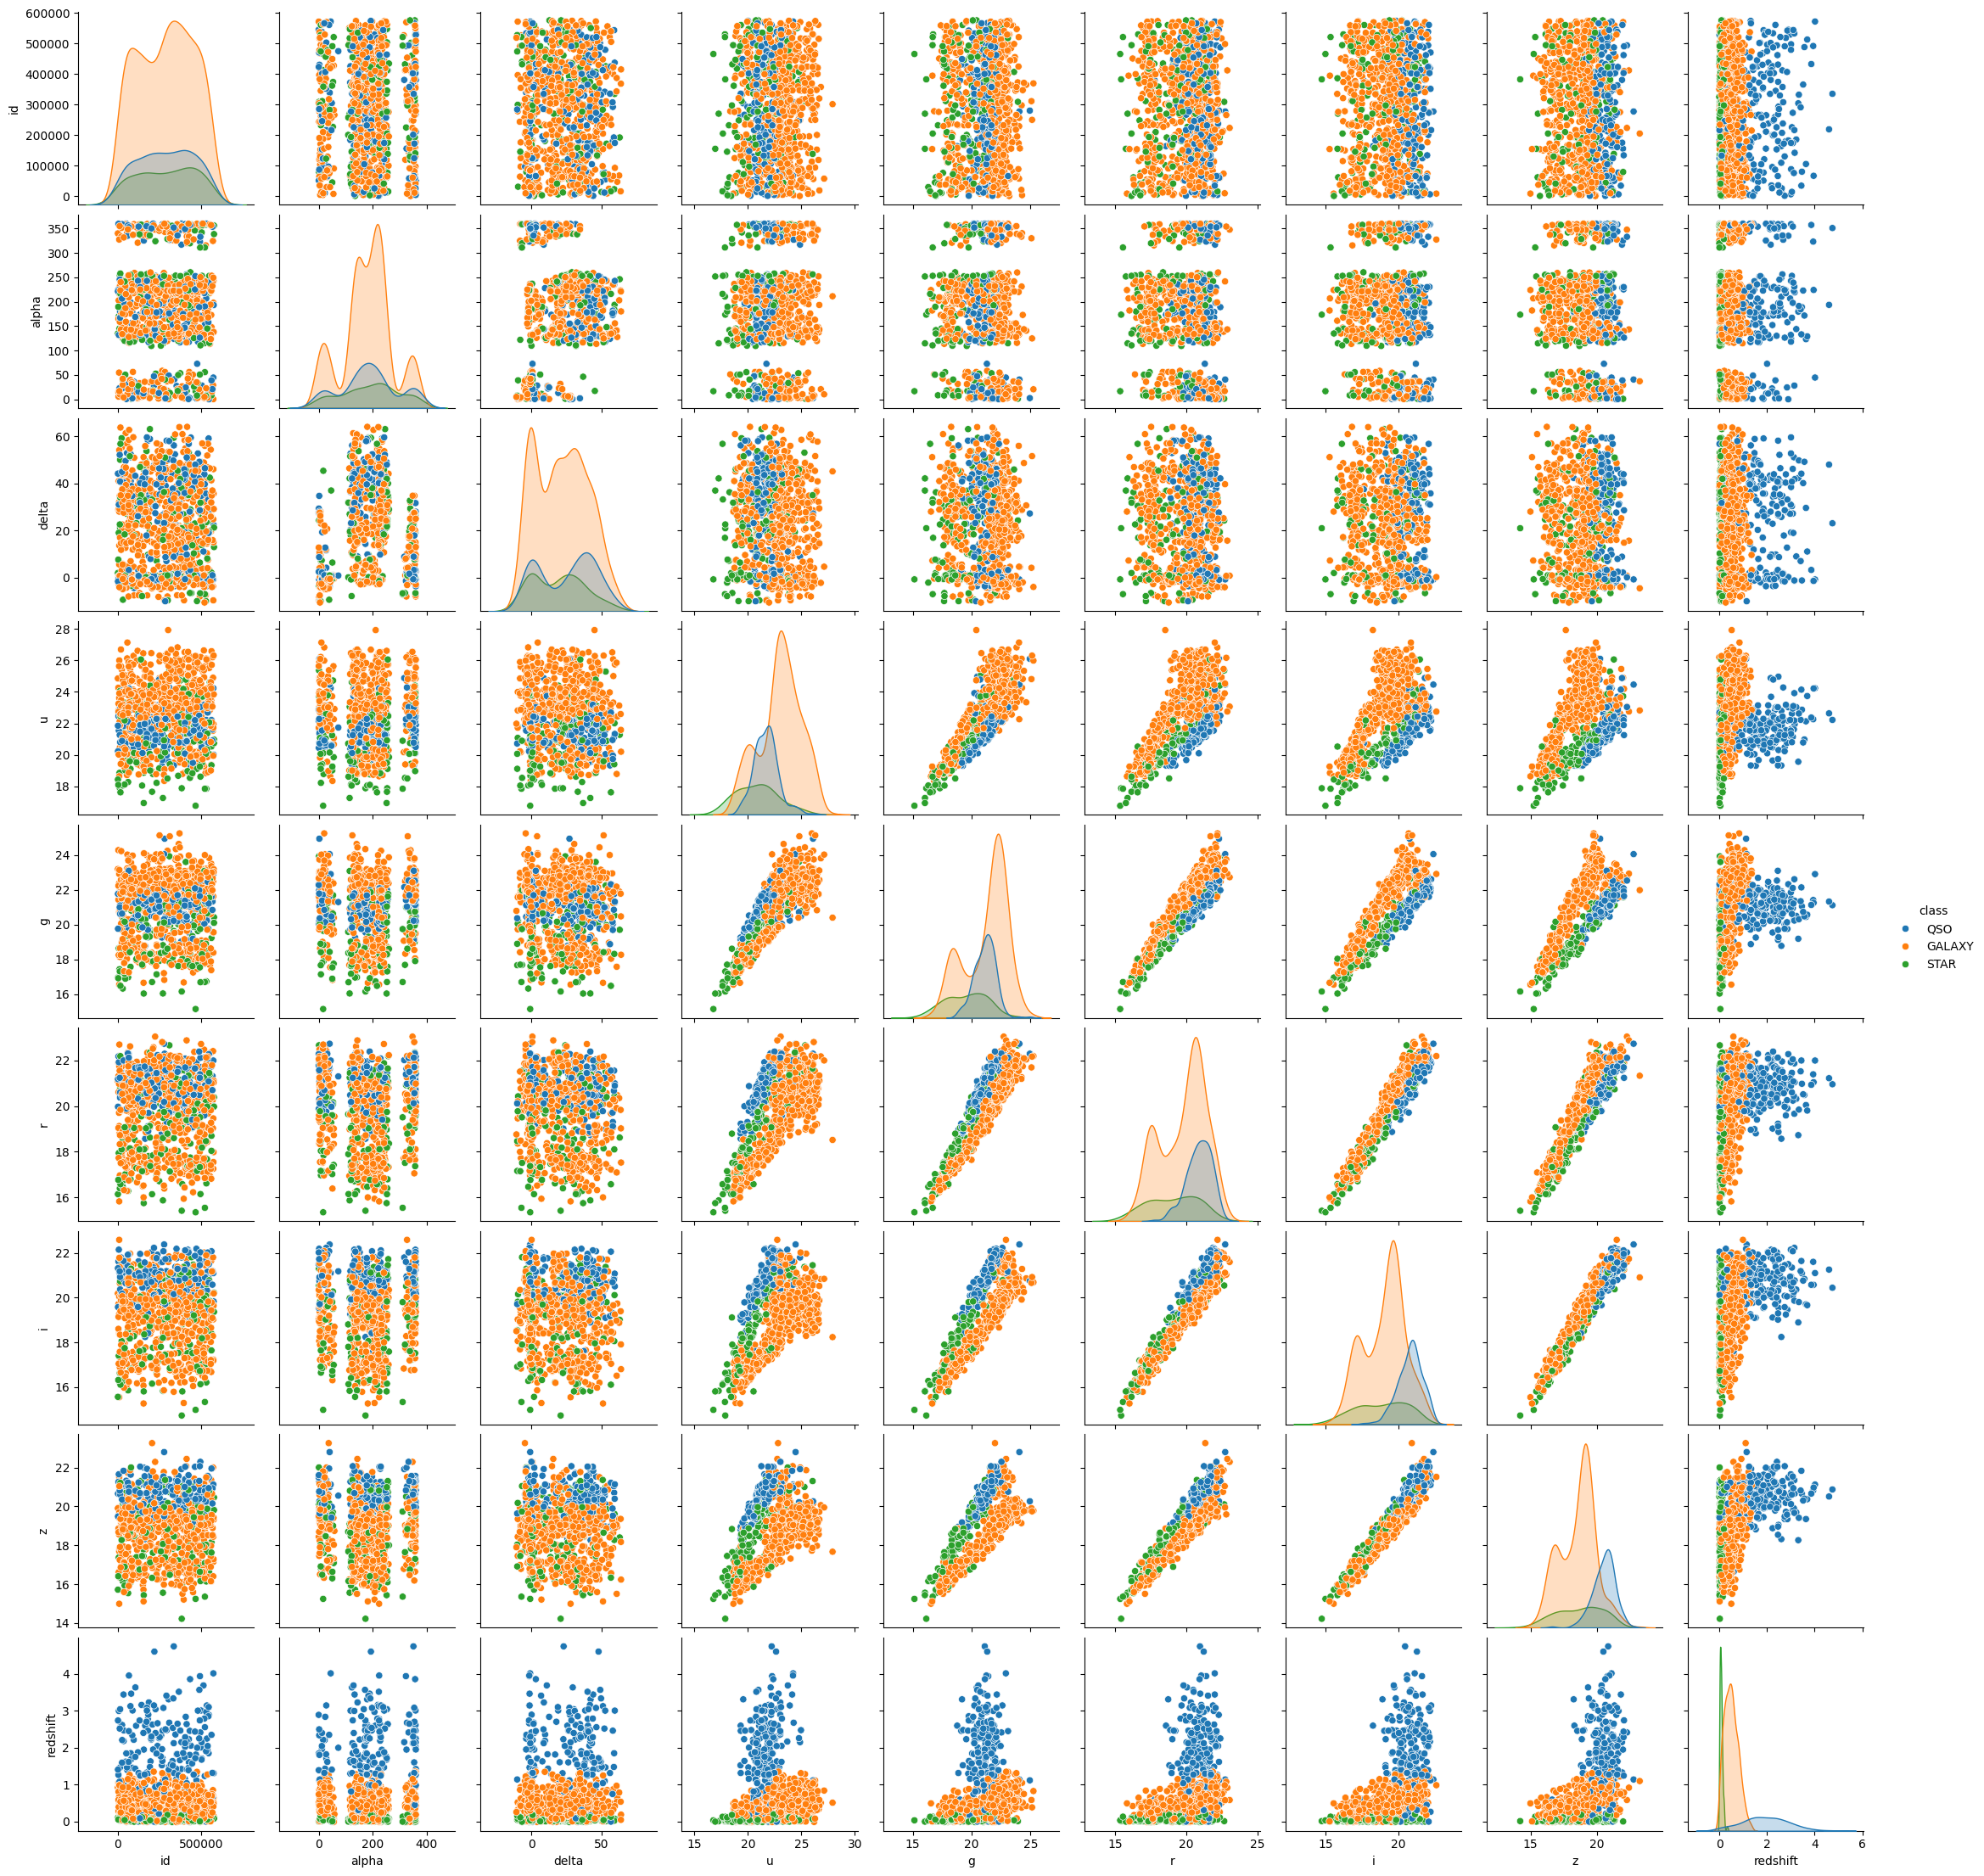

In [17]:
sns.pairplot(df.sample(1000),hue = 'class')

<Axes: xlabel='galaxy_population', ylabel='alpha'>

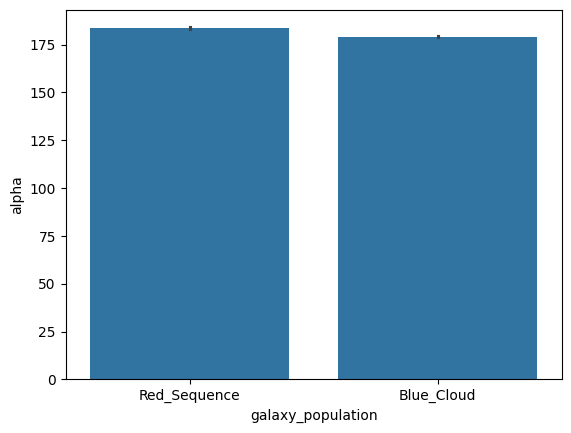

In [18]:
sns.barplot(data = df,x='galaxy_population',y= 'alpha',legend='auto')

scaling the numeric columns

In [19]:
df.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population', 'class'],
      dtype='object')

In [20]:
main_df = df.iloc[:,1:]

In [21]:
main_df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [22]:
test_df = test_df.iloc[:,1:]

In [23]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [24]:
train_df , val_df = train_test_split(main_df,test_size=0.2,random_state=42)

In [25]:
numeric_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z','redshift']
categorical_cols = ['spectral_type', 'galaxy_population']

In [26]:
target_cols = 'class'

In [27]:
from sklearn.preprocessing import MinMaxScaler

In [28]:
scaler = MinMaxScaler()

In [29]:
main_df[numeric_cols]

,alpha,delta,u,g,r,i,z,redshift
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761
...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359


In [30]:
train_df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
203558,203.472222,45.068529,20.867021,21.160233,20.945504,20.818884,20.393731,2.009554,A/F,Blue_Cloud,QSO
6644,147.945352,35.735903,20.568492,20.399217,20.924654,20.451658,20.441996,2.616479,O/B,Blue_Cloud,QSO
514980,13.559656,-0.923788,21.938553,20.135178,18.355262,17.976637,17.443614,0.535841,M,Red_Sequence,GALAXY
140990,231.842122,44.995057,25.692615,21.854658,20.699591,19.555213,19.060713,0.687786,M,Red_Sequence,GALAXY
43963,45.826897,0.394923,19.767019,18.152736,17.146297,17.081129,16.566791,0.305880,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...
110268,152.926236,39.882518,23.225575,22.621515,22.167105,21.968925,20.902013,1.872303,A/F,Blue_Cloud,QSO
259178,123.712821,25.838149,20.803271,20.650012,20.494962,20.152450,19.779036,1.765592,A/F,Blue_Cloud,QSO
365838,254.102616,31.376847,21.493177,21.351525,21.050940,21.311095,20.773733,0.981010,A/F,Blue_Cloud,QSO
131932,127.966940,39.968811,20.007825,18.629477,17.920148,17.781188,17.458535,0.059806,G/K,Blue_Cloud,GALAXY


In [31]:
val_df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
257748,349.754526,2.068116,22.095457,21.498779,21.473201,21.027874,20.538771,1.061478,A/F,Blue_Cloud,QSO
177851,186.059054,-0.737203,22.493559,20.856920,20.547124,20.633777,20.147681,0.023361,A/F,Blue_Cloud,STAR
562767,230.857281,-1.384550,19.270161,19.370643,19.619284,19.081332,19.117362,1.757464,O/B,Blue_Cloud,QSO
351391,128.405956,11.065310,23.024219,21.692118,20.694775,20.015808,19.551627,0.931297,G/K,Red_Sequence,GALAXY
12001,200.059936,14.247050,23.094053,23.083620,20.699041,19.932680,19.412558,0.723954,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...
441297,248.898843,37.507597,20.647194,20.044501,19.975385,19.723394,19.308995,3.078486,A/F,Blue_Cloud,QSO
270941,179.724260,33.791773,21.589796,21.202466,21.629728,21.051495,20.894204,0.486962,O/B,Blue_Cloud,QSO
344187,354.453130,8.578812,23.998291,22.106595,20.889650,20.156614,20.572405,0.012750,M,Red_Sequence,STAR
436313,231.258499,36.252886,22.920766,20.878814,19.138548,18.901368,17.988486,0.275097,M,Red_Sequence,GALAXY


In [32]:
train_df[target_cols]

,class
203558,QSO
6644,QSO
514980,GALAXY
140990,GALAXY
43963,GALAXY
...,...
110268,QSO
259178,QSO
365838,QSO
131932,GALAXY


In [33]:
val_df[target_cols]

,class
257748,QSO
177851,STAR
562767,QSO
351391,GALAXY
12001,GALAXY
...,...
441297,QSO
270941,QSO
344187,STAR
436313,GALAXY


In [34]:
scaler.fit(main_df[numeric_cols])

MinMaxScaler()

In [35]:
train_df[numeric_cols] = scaler.transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [36]:
train_df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
203558,0.565187,0.649012,0.739852,0.541349,0.660042,0.555309,0.575204,0.287651,A/F,Blue_Cloud,QSO
6644,0.410940,0.552924,0.729338,0.487318,0.658397,0.532282,0.578391,0.374098,O/B,Blue_Cloud,QSO
514980,0.037634,0.175476,0.777592,0.468571,0.455685,0.377090,0.380401,0.077743,M,Red_Sequence,GALAXY
140990,0.643995,0.648256,0.909812,0.590652,0.640641,0.476072,0.487182,0.099385,M,Red_Sequence,GALAXY
43963,0.127269,0.189054,0.701110,0.327820,0.360304,0.320938,0.322502,0.044988,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...
110268,0.424777,0.595617,0.822922,0.645098,0.756420,0.627420,0.608767,0.268101,A/F,Blue_Cloud,QSO
259178,0.343626,0.451017,0.737607,0.505124,0.624497,0.513521,0.534614,0.252902,A/F,Blue_Cloud,QSO
365838,0.705831,0.508043,0.761906,0.554930,0.668361,0.586172,0.600297,0.141150,A/F,Blue_Cloud,QSO
131932,0.355443,0.596506,0.709591,0.361668,0.421357,0.364834,0.381386,0.009939,G/K,Blue_Cloud,GALAXY


In [37]:
train_df.describe()

,alpha,delta,u,g,r,i,z,redshift
count,461877.000000,461877.000000,461877.000000,461877.000000,461877.000000,461877.000000,461877.000000,461877.000000
mean,0.504315,0.409701,0.795401,0.530664,0.582762,0.465212,0.486087,0.104546
std,0.267377,0.194914,0.071070,0.127391,0.130027,0.099037,0.104572,0.115626
min,0.000000,0.000000,0.000000,0.004966,0.007691,0.000000,0.000000,0.000000
25%,0.366866,0.210429,0.743863,0.449902,0.492919,0.398113,0.415800,0.027228
50%,0.524047,0.405698,0.799923,0.563319,0.619707,0.481043,0.495808,0.072402
75%,0.643928,0.565725,0.845686,0.621864,0.677476,0.542291,0.560259,0.127015
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [38]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 461877 entries, 203558 to 121958
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              461877 non-null  float64
 1   delta              461877 non-null  float64
 2   u                  461877 non-null  float64
 3   g                  461877 non-null  float64
 4   r                  461877 non-null  float64
 5   i                  461877 non-null  float64
 6   z                  461877 non-null  float64
 7   redshift           461877 non-null  float64
 8   spectral_type      461877 non-null  object 
 9   galaxy_population  461877 non-null  object 
 10  class              461877 non-null  object 
dtypes: float64(8), object(3)
memory usage: 42.3+ MB


In [39]:
val_df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
257748,0.971540,0.206281,0.783118,0.565385,0.701675,0.568413,0.584781,0.152612,A/F,Blue_Cloud,QSO
177851,0.516815,0.177397,0.797140,0.519814,0.628612,0.543702,0.558957,0.004748,A/F,Blue_Cloud,STAR
562767,0.641259,0.170732,0.683610,0.414290,0.555410,0.446358,0.490922,0.251744,O/B,Blue_Cloud,QSO
351391,0.356663,0.298916,0.815830,0.579112,0.640261,0.504953,0.519598,0.134069,G/K,Red_Sequence,GALAXY
12001,0.555708,0.331675,0.818290,0.677907,0.640598,0.499741,0.510415,0.104536,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...
441297,0.691376,0.571165,0.732110,0.462133,0.583505,0.486618,0.503576,0.439904,A/F,Blue_Cloud,QSO
270941,0.499218,0.532907,0.765309,0.544347,0.714024,0.569894,0.608252,0.070780,O/B,Blue_Cloud,QSO
344187,0.984592,0.273315,0.850137,0.608540,0.655636,0.513782,0.587002,0.003236,M,Red_Sequence,STAR
436313,0.642373,0.558247,0.812186,0.521368,0.517483,0.435074,0.416380,0.040604,M,Red_Sequence,GALAXY


Encoding the categorical columns

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
train_df[categorical_cols]

,spectral_type,galaxy_population
203558,A/F,Blue_Cloud
6644,O/B,Blue_Cloud
514980,M,Red_Sequence
140990,M,Red_Sequence
43963,M,Red_Sequence
...,...,...
110268,A/F,Blue_Cloud
259178,A/F,Blue_Cloud
365838,A/F,Blue_Cloud
131932,G/K,Blue_Cloud


In [42]:
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded_cols = list(encoder.fit_transform(train_df[categorical_cols]))

In [43]:
encoded_cols

[array([1., 0., 0., 0., 1., 0.]),
 array([0., 0., 0., 1., 1., 0.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 1., 0., 0., 1., 0.]),
 array([0., 1., 0., 0., 0., 1.]),
 array([1., 0., 0., 0., 1., 0.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 0., 0., 1., 1., 0.]),
 array([1., 0., 0., 0., 1., 0.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([1., 0., 0., 0., 1., 0.]),
 array([0., 0., 0., 1., 1., 0.]),
 array([1., 0., 0., 0., 0., 1.]),
 array([0., 1., 0., 0., 0., 1.]),
 array([1., 0., 0., 0., 1., 0.]),
 array([0., 1., 0., 0., 0., 1.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 1., 0., 0., 1., 0.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 0., 1., 0., 1., 0.]),
 array([0., 0., 1., 0., 1., 0.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([1., 0., 0., 0., 1., 0.]),
 array([0., 0., 1., 0., 0., 1.]),
 array([0., 1.

In [44]:
encoded_cols = encoder.get_feature_names_out(categorical_cols)

train_df[encoded_cols] = encoder.transform(train_df[categorical_cols])
val_df[encoded_cols] = encoder.transform(val_df[categorical_cols])
test_df[encoded_cols] = encoder.transform(test_df[categorical_cols])

train_df.drop(columns=categorical_cols, inplace=True)
val_df.drop(columns=categorical_cols, inplace=True)
test_df.drop(columns=categorical_cols, inplace=True)

In [45]:
train_df

,alpha,delta,u,g,r,i,z,redshift,class,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
203558,0.565187,0.649012,0.739852,0.541349,0.660042,0.555309,0.575204,0.287651,QSO,1.0,0.0,0.0,0.0,1.0,0.0
6644,0.410940,0.552924,0.729338,0.487318,0.658397,0.532282,0.578391,0.374098,QSO,0.0,0.0,0.0,1.0,1.0,0.0
514980,0.037634,0.175476,0.777592,0.468571,0.455685,0.377090,0.380401,0.077743,GALAXY,0.0,0.0,1.0,0.0,0.0,1.0
140990,0.643995,0.648256,0.909812,0.590652,0.640641,0.476072,0.487182,0.099385,GALAXY,0.0,0.0,1.0,0.0,0.0,1.0
43963,0.127269,0.189054,0.701110,0.327820,0.360304,0.320938,0.322502,0.044988,GALAXY,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,0.424777,0.595617,0.822922,0.645098,0.756420,0.627420,0.608767,0.268101,QSO,1.0,0.0,0.0,0.0,1.0,0.0
259178,0.343626,0.451017,0.737607,0.505124,0.624497,0.513521,0.534614,0.252902,QSO,1.0,0.0,0.0,0.0,1.0,0.0
365838,0.705831,0.508043,0.761906,0.554930,0.668361,0.586172,0.600297,0.141150,QSO,1.0,0.0,0.0,0.0,1.0,0.0
131932,0.355443,0.596506,0.709591,0.361668,0.421357,0.364834,0.381386,0.009939,GALAXY,0.0,1.0,0.0,0.0,1.0,0.0


In [46]:
train_targets = train_df[target_cols]
val_targets = val_df[target_cols]

In [47]:
train_inputs = train_df[numeric_cols + list(encoded_cols)]
val_inputs = val_df[numeric_cols + list(encoded_cols)]
test_inputs = test_df[numeric_cols + list(encoded_cols)]

Try different models

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [49]:
from sklearn.metrics import root_mean_squared_error,accuracy_score

In [50]:
!pip install xgboost --quiet

Labeling the target columns

In [51]:
type(train_targets)

pandas.core.series.Series

In [52]:
from sklearn.preprocessing import LabelEncoder
Lencoder = LabelEncoder()
train_targets = Lencoder.fit_transform(train_targets)
val_targets = Lencoder.transform(val_targets)

In [53]:
def make_predict(model):
  model.fit(train_inputs,train_targets)
  train_preds = model.predict(train_inputs)
  val_preds = model.predict(val_inputs)
  train_rmse = np.sqrt(root_mean_squared_error(train_targets,train_preds))
  val_rmse = np.sqrt(root_mean_squared_error(val_targets,val_preds))
  return train_preds,val_preds,train_rmse,val_rmse

first Linear models

In [54]:
model1 = LogisticRegression(multi_class='multinomial',solver='lbfgs')
train_preds1,val_preds1,train_rmse1,val_rmse1 = make_predict(model1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
train_rmse1,val_rmse1

(np.float64(0.6665040909958988), np.float64(0.666798966847665))

In [56]:
accuracy_score(train_targets,train_preds1)

0.9271234549457973

In [57]:
accuracy_score(val_targets,val_preds1)

0.9271499090672902

In [58]:
# predict the test set
test_preds1 = model1.predict(test_inputs)

In [59]:
test_preds1 = Lencoder.inverse_transform(test_preds1)

In [60]:
test_preds1

array(['GALAXY', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'QSO', 'GALAXY'],
      dtype=object)

In [61]:
sub_df['class'] = test_preds1

In [62]:
sub_df.to_csv('logistic_sub.csv',index=False)

In [63]:
%%time
model2 = RandomForestClassifier(random_state=42,n_estimators=100,max_depth = 10,n_jobs = -1)
train_preds2,val_preds2,train_rmse2,val_rmse2 = make_predict(model2)

CPU times: user 4min 13s, sys: 605 ms, total: 4min 13s
Wall time: 2min 47s


In [64]:
accuracy_score(train_targets,train_preds2) , accuracy_score(val_targets,val_preds2)

(0.9497874975372231, 0.9470252013510002)

In [65]:
train_rmse2 , val_rmse2

(np.float64(0.6191545599273124), np.float64(0.6271147170508481))

In [66]:
test_preds2 = model2.predict(test_inputs)

In [67]:
test_preds2 = Lencoder.inverse_transform(test_preds2)

In [68]:
test_preds2.shape , test_inputs.shape

((247435,), (247435, 14))

In [69]:
sub_df['class'] = test_preds2

In [70]:
sub_df.to_csv("RandomForest_sub.csv",index = False)

xgboost model


In [71]:
import xgboost as xgb
model3 = xgb.XGBClassifier(random_state=42,n_estimators=200,max_depth = 15,n_jobs = -1,learning_rate=0.3)
train_preds3,val_preds3,train_rmse3,val_rmse3 = make_predict(model3)

In [72]:
train_preds3,val_preds3 , train_rmse3,val_rmse3

(array([1, 1, 0, ..., 1, 0, 0]),
 array([1, 2, 1, ..., 2, 0, 0]),
 np.float64(0.0),
 np.float64(0.5454513935088029))

In [73]:
accuracy_score(train_targets,train_preds3) , accuracy_score(val_targets,val_preds3)

(1.0, 0.9670823590542998)

In [74]:
test_pred3 = model3.predict(test_inputs)


In [75]:
test_pred3 = Lencoder.inverse_transform(test_pred3)

In [76]:
sub_df['class'] = test_pred3

In [77]:
sub_df.to_csv("xgboost_sub.csv",index = False)

In [78]:
%%time
model4 = xgb.XGBClassifier(random_state=42,n_estimators=1000,max_depth = 18,n_jobs = -1,learning_rate=0.01)
train_preds4,val_preds4,train_rmse4,val_rmse4 = make_predict(model4)

CPU times: user 27min 42s, sys: 6.6 s, total: 27min 49s
Wall time: 16min 2s


In [79]:
accuracy_score(train_targets,train_preds4) , accuracy_score(val_targets,val_preds4)

(0.999839784184967, 0.9658093011171733)

In [80]:
test_preds4 = model4.predict(test_inputs)

In [81]:
test_preds4 = Lencoder.inverse_transform(test_preds4)

In [82]:
test_preds4

array(['GALAXY', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'QSO', 'GALAXY'],
      dtype=object)

In [83]:
sub_df['class'] = test_preds4;

In [84]:
sub_df.to_csv("xgbclassifier2.csv",index = False)

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

First Try with a random Hyperparameter

In [86]:
%%time
model5 = GradientBoostingClassifier(random_state=42,n_estimators=100,max_depth = 5,
                                    learning_rate=0.3,subsample=0.9,
                                    min_samples_split=10,min_samples_leaf=5)
train_preds5,val_preds5,train_rmse5,val_rmse5 = make_predict(model5)

CPU times: user 30min 13s, sys: 951 ms, total: 30min 14s
Wall time: 30min 27s


In [87]:
accuracy_score(train_targets,train_preds5) , accuracy_score(val_targets,val_preds5)

(0.9698707664594687, 0.9654628907941457)

In [88]:
test_preds5 = model5.predict(test_inputs)

In [89]:
test_preds5 = Lencoder.inverse_transform(test_preds5)

In [90]:
test_preds5

array(['GALAXY', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'QSO', 'GALAXY'],
      dtype=object)

In [91]:
sub_df['class'] = test_preds5

In [92]:
sub_df.to_csv("GradientBoosting_sub.csv",index = False)

In [93]:
from sklearn.metrics import classification_report

In [94]:
print(classification_report(val_targets,val_preds5))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     75694
           1       0.97      0.96      0.96     23243
           2       0.92      0.92      0.92     16533

    accuracy                           0.97    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.97      0.97      0.97    115470



In [95]:
!pip install lightgbm --quiet

In [96]:
from lightgbm import LGBMClassifier

In [97]:
model7 = LGBMClassifier(
      n_estimators=500,
      learning_rate=0.05,
      max_depth=-1,       # -1 means no limit
      subsample=0.8,
      colsample_bytree=0.8,
      random_state=42
)
train_preds7,val_preds7,train_rmse7,val_rmse7 = make_predict(model7)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 14
[LightGBM] [Info] Start training from score -0.425580
[LightGBM] [Info] Start training from score -1.593068
[LightGBM] [Info] Start training from score -1.942754


In [98]:
accuracy_score(train_targets,train_preds7) , accuracy_score(val_targets,val_preds7)

(0.9695611602223103, 0.9655321728587511)

In [100]:
test_preds7 = model7.predict(test_inputs)

In [101]:
test_preds7

array([0, 0, 0, ..., 0, 1, 0])

In [102]:
test_pred7 = Lencoder.inverse_transform(test_preds7)

In [103]:
sub_df['class'] = test_pred7

In [104]:
sub_df.to_csv("lgbm_sub1.csv",index = False)

In [107]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
model8_standard = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=1.0,
        max_iter=5000,
        dual=False,
        random_state=42
    )
)
train_preds8,val_preds8,train_rmse8,val_rmse8 = make_predict(model8_standard)

In [108]:
train_preds8,val_preds8 , train_rmse8,val_rmse8

(array([1, 1, 0, ..., 1, 2, 0]),
 array([1, 2, 1, ..., 0, 0, 0]),
 np.float64(0.6760237963866024),
 np.float64(0.6760892637391878))

In [109]:
test_preds8 = model8_standard.predict(test_inputs)

In [110]:
test_preds8 = Lencoder.inverse_transform(test_preds8)

In [113]:
test_preds8.shape, test_inputs.shape

((247435,), (247435, 14))

In [116]:
sub_df['class'] = test_preds8

In [117]:
sub_df.to_csv("LinearSVC_sub.csv",index = False)

Now at this time xgboost has the score

I will tune the hyperparameter further for that

In [119]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

def tune_xgboost(
    X_train,
    y_train,
    cv=3,
    n_iter=30,
    scoring='f1_macro',  # or 'accuracy'
    random_state=42,
    n_jobs=-1
):
    """
    Tune XGBoost using RandomizedSearchCV.

    Returns:
        best_model
        best_params
        best_score
    """

    xgb = XGBClassifier(
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=random_state
    )

    param_dist = {
        "n_estimators": randint(200, 1000),
        "max_depth": randint(3, 12),
        "learning_rate": uniform(0.01, 0.19),
        "subsample": uniform(0.7, 0.3),
        "colsample_bytree": uniform(0.7, 0.3),
        "min_child_weight": randint(1, 10),
        "gamma": uniform(0, 5),
        "reg_alpha": uniform(0, 2),
        "reg_lambda": uniform(0.5, 3)
    }

    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        verbose=2,
        n_jobs=n_jobs,
        random_state=random_state
    )

    search.fit(X_train, y_train)

    return (
        search.best_estimator_,
        search.best_params_,
        search.best_score_
    )

In [120]:
best_model, best_params, best_score = tune_xgboost(
    train_inputs,
    train_targets,
    cv=3,
    n_iter=20,
    scoring='f1_macro'
)

print(best_params)
print(best_score)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'colsample_bytree': np.float64(0.7323674280979913), 'gamma': np.float64(0.15714592843367126), 'learning_rate': np.float64(0.13091797814011827), 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 933, 'reg_alpha': np.float64(0.2786629088117514), 'reg_lambda': np.float64(2.3132521378334516), 'subsample': np.float64(0.8619523273905019)}
0.9549257747947001


In [121]:
model9_xgboost_tune = best_model

In [122]:
train_preds9 = model9_xgboost_tune.predict(train_inputs)
val_preds9 = model9_xgboost_tune.predict(val_inputs)

In [123]:
accuracy_score(train_targets,train_preds9) , accuracy_score(val_targets,val_preds9)

(0.9828287617699084, 0.9682947951848965)

In [125]:
test_preds9 = model9_xgboost_tune.predict(test_inputs)

In [126]:
test_preds9 = Lencoder.inverse_transform(test_preds9)

In [127]:
sub_df['class'] = test_preds9

In [128]:
sub_df.to_csv("xgboost_tune_sub.csv",index = False)

In [129]:
importance = pd.DataFrame({
    'feature': test_inputs.columns,
    'importance': model9_xgboost_tune.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(10))

                           feature  importance
10                 spectral_type_M    0.653896
12    galaxy_population_Blue_Cloud    0.105851
7                         redshift    0.085914
13  galaxy_population_Red_Sequence    0.063173
9                spectral_type_G/K    0.018303
6                                z    0.016618
3                                g    0.015074
2                                u    0.010255
5                                i    0.008278
4                                r    0.007106
